In [1]:
%run ../../../bootstrap.py

[Bootstrap] cwd=/home/ikk/renal-calculi-classificaction | seed=57


In [2]:
from src.data.dataset import KidneyStoneDataset
from src.data.dataset_builder import DatasetBuilder, assign_task_labels
from src.pipelines.hybrid_resnet50_pipeline import HybridResNet50_pipeline
import pandas as pd
from src.features.feature_extractor import FeatureExtractor
from src.features.lbp import LocalBinaryPattern
from src.features.hsv import HSV_extractor
from src.pipelines.xgboost_pipeline import XGBoostExperiment

In [3]:
task_name = "binario"
task_config = TASKS[task_name]
builder = DatasetBuilder(DATASET_PATH)
xgboost_builder= DatasetBuilder(DATASET_PATH_XGBOOST)

df = builder.build(classes=task_config["classes"])
xgboost_df = xgboost_builder.build(classes=task_config["classes"])

lbp = LocalBinaryPattern)
hsv = HSV_extractor()
extractor = FeatureExtractor(hsv, lbp)
resnet50_model= HybridResNet50_pipeline(df= df, xgboost_df= xgboost_df, case=Case.IMAGE, extractor= extractor)

[INFO] HybridResNet50_pipeline inicializado:
  - 397 muestras en df
  - 397 descriptores indexados por match_key
  - Dimensión handcrafted: 40



EXPERIMENTO K-FOLD: hybrid_resnet50_binario
Total images: 397
K-folds: 5 | Validación interna: 15% del train

--- Fold 1/5 ---
  Train: 267 images (215 cálculos)
  Val:   39 images (34 cálculos)
  Test:  91 images (63 cálculos)
Device: cuda
Trainable parameters: 535,810
Epochs: 30, LR: 0.0001, Weight decay: 0.0001
Epoch   1/30 | train: loss=0.5457 acc=0.7045 f1=0.7045 | val: loss=0.5146 acc=0.9231 f1=0.9211 | lr=1.00e-04 | 9.7s
Epoch   2/30 | train: loss=0.4502 acc=0.7917 f1=0.7915 | val: loss=0.3844 acc=0.8974 f1=0.8958 | lr=1.00e-04 | 9.4s
Epoch   3/30 | train: loss=0.3666 acc=0.8523 f1=0.8523 | val: loss=0.3443 acc=0.8974 f1=0.8958 | lr=1.00e-04 | 9.7s
Epoch   4/30 | train: loss=0.3794 acc=0.8371 f1=0.8368 | val: loss=0.3836 acc=0.8205 f1=0.8227 | lr=1.00e-04 | 8.6s
Epoch   5/30 | train: loss=0.3880 acc=0.8182 f1=0.8183 | val: loss=0.3363 acc=0.9231 f1=0.9225 | lr=1.00e-04 | 8.1s
Epoch   6/30 | train: loss=0.3304 acc=0.8598 f1=0.8599 | val: loss=0.3251 acc=0.9231 f1=0.9211 | lr=1.0

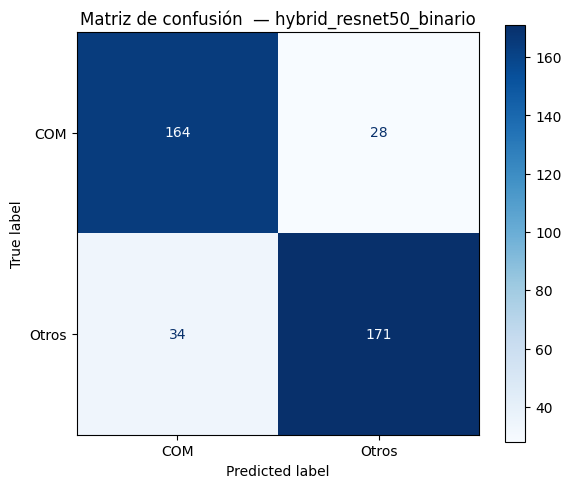


RESULTADOS CV 5 -fold (media ± std entre folds):
  accuracy: 0.8430 ± 0.0302
  auc_weighted: 0.9231 ± 0.0220
  f1_weighted: 0.8432 ± 0.0301
  npv_weighted: 0.8388 ± 0.0336
  precision_weighted: 0.8467 ± 0.0284
  recall_weighted: 0.8430 ± 0.0302
  specificity_weighted: 0.8451 ± 0.0301


In [6]:

config = {
    "name": f"hybrid_resnet50_{task_name}",
    "output_dir": f"experiments/hybrid_resnet50/hybrid_resnet50_images/hybrid_resnet50_{task_name}",
    "class_names": task_config["class_names"],
    "batch_size": 8
}


resnet50_model.run_model(config, show_fold_metrics= True)


